# Ticket to Ride
![title](TTR_america_map.webp)
## Value of route length

In [1]:
import pandas as pd
import seaborn as sns
pd.set_option('display.float_format', '{:.2f}'.format)

CARS_PER_TURN = 2 # number of cards a player can pick up per turn
ROUTE_LENGTHS = pd.DataFrame({
    "Cars": [1,2,3,4,5,6],
    "Points": [1,2,4,7,10,15]
},
index=[1,2,3,4,5,6]);
ROUTE_LENGTHS["Total Turns to Claim"] = 1+ROUTE_LENGTHS.Cars/CARS_PER_TURN
ROUTE_LENGTHS["Points per Turn"] = ROUTE_LENGTHS.Points/(1+ROUTE_LENGTHS.Cars/CARS_PER_TURN)
ROUTE_LENGTHS["Cars per Turn"] = ROUTE_LENGTHS.Cars/(1+ROUTE_LENGTHS.Cars/CARS_PER_TURN)

def set_style(styler):
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True), subset=["Points per Turn", "Cars per Turn"])
    styler.hide(axis=0) # Hides index column
    styler.format(precision=2)
    return styler

ROUTE_LENGTHS.style.pipe(set_style)

Cars,Points,Total Turns to Claim,Points per Turn,Cars per Turn
1,1,1.50,0.67,0.67
2,2,2.00,1.00,1.00
3,4,2.50,1.60,1.20
4,7,3.00,2.33,1.33
5,10,3.50,2.86,1.43
6,15,4.00,3.75,1.50


<Axes: xlabel='Cars'>

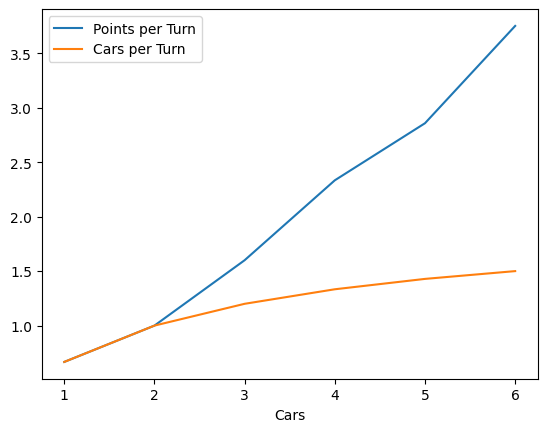

In [2]:
ROUTE_LENGTHS.plot(x="Cars", y=["Points per Turn", "Cars per Turn"])

## Routes Matrix

In [3]:
from collections import defaultdict
ROUTES_MATRIX = pd.read_csv("america_routes.csv").fillna(value=0)
def set_style(styler):
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True))
    styler.hide(axis=0) # Hides index column
    styler.format(precision=0)
    styler.set_table_styles(
    [dict(selector="th",props=[('max-width', '80px')]),
        dict(selector="th.col_heading",
                 props=[("writing-mode", "vertical-rl"), 
                        ('vertical-align', 'text-top'), ('transform', 'rotateZ(180deg)'),
                        ])])
    return styler
ROUTES_MATRIX.style.pipe(set_style)

City,Atlanta,Boston,Calgary,Charleston,Chicago,Dallas,Denver,Duluth,El Paso,Helena,Houston,Kansas City,Las Vegas,Little Rock,Los Angeles,Miami,Montreal,Nashville,New Orleans,New York,Oklahoma City,Omaha,Phoenix,Pittsburgh,Portland,Raleigh,Saint Louis,Salt Lake City,San Francisco,Santa Fe,Sault St. Marie,Seattle,Toronto,Vancouver,Washington,Winnipeg
Atlanta,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,5,0,1,4,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
Boston,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Calgary,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,3,0,6
Charleston,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
Chicago,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,3,0,0,2,0,0,0,0,0,4,0,0,0
Dallas,0,0,0,0,0,0,0,0,4,0,1,0,0,2,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Denver,0,0,0,0,0,0,0,0,0,4,0,4,0,0,0,0,0,0,0,0,4,4,5,0,0,0,0,3,0,2,0,0,0,0,0,0
Duluth,0,0,0,0,3,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,3,0,6,0,0,4
El Paso,0,0,0,0,0,4,0,0,0,0,6,0,0,0,6,0,0,0,0,0,5,0,3,0,0,0,0,0,0,2,0,0,0,0,0,0
Helena,0,0,4,0,0,0,4,6,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,3,0,0,0,6,0,0,0,4


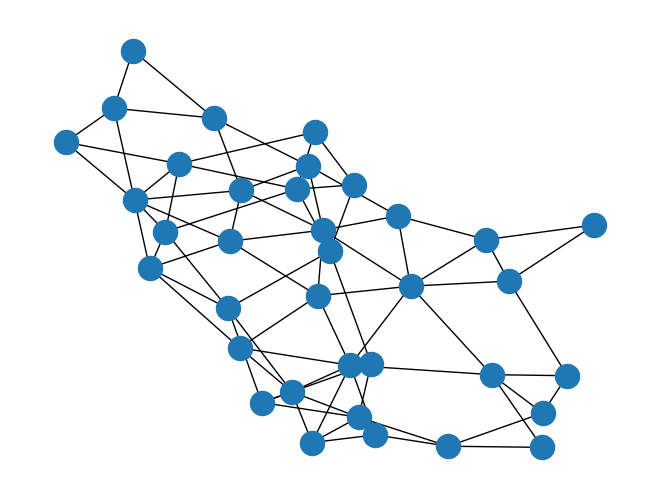

In [32]:
## Routes graph visualized
import networkx as nx
ROUTES_GRAPH = nx.Graph()
for i, row in ROUTES_MATRIX.iterrows():
    for j in range(1, len(row)):
        route_length = row[ROUTES_MATRIX.columns[j]]
        weight = route_length # TODO: need to weight by number of turns and/or points/turn
        if weight > 0:
            ROUTES_GRAPH.add_edge(i,j-1,weight=weight)
nx.draw(ROUTES_GRAPH)

## Rush Strategy
* Ignore tickets (take the minimum starting tickets, and only take the lowest valued ones)
* Claim the longest routes possible
* End the game as fast as possible

In [4]:
from collections import defaultdict

STARTING_CARS = 3 # Number of cards each player starts with
TOTAL_TRAIN_CARS = 45 # Number of train cars each player starts with
CARS_REMAINING_TO_END_GAME = 2 # When a player has equal to or less than this number of cars, each player has one more turn remaining before the game ends
routes_claimed_sets = []
for number_of_sixroutes_allowed in reversed(range(1,8)):
    routes_claimed_set = {i:0 for i in range(1,7)}
    train_cars_remaining = TOTAL_TRAIN_CARS
    sixroutes_remaining = number_of_sixroutes_allowed
    while train_cars_remaining > 0:
        if train_cars_remaining <= 5:
            routes_claimed_set[train_cars_remaining] += 1
            train_cars_remaining = 0
            continue
        if sixroutes_remaining > 0:
            routes_claimed_set[6] += 1
            sixroutes_remaining -= 1
            train_cars_remaining -= 6
            continue
        routes_claimed_set[5] += 1
        train_cars_remaining -= 5
    routes_claimed_sets.append(routes_claimed_set)

RUSH_MOVESETS = pd.DataFrame(routes_claimed_sets)
RUSH_MOVESETS["Turns"] = sum(
        [RUSH_MOVESETS[rte_length] * ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == rte_length, "Total Turns to Claim"].iloc[0] for rte_length in range(1,7)]
    ) - STARTING_CARS/CARS_PER_TURN
RUSH_MOVESETS["Points"] = sum(
        [RUSH_MOVESETS[rte_length] * ROUTE_LENGTHS.loc[ROUTE_LENGTHS["Cars"] == rte_length, "Points"].iloc[0] for rte_length in range(1,7)]
    )
RUSH_MOVESETS["Points per Turn"] = RUSH_MOVESETS["Points"] / RUSH_MOVESETS["Turns"]
RUSH_MOVESETS["Cars per Turn"] = TOTAL_TRAIN_CARS / RUSH_MOVESETS["Turns"]

def set_style(styler):
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True).reversed(), subset=["Turns"])
    styler.background_gradient(cmap=sns.light_palette("seagreen", as_cmap=True), subset=["Points", "Points per Turn", "Cars per Turn"])
    styler.hide(axis=0) # Hides index column
    styler.format(precision=2)
    styler.format(precision=0, subset=["Turns"])
    return styler

RUSH_MOVESETS.style.pipe(set_style)

1,2,3,4,5,6,Turns,Points,Points per Turn,Cars per Turn
0,0,1,0,0,7,29,109,3.76,1.55
0,0,0,1,1,6,29,107,3.69,1.55
0,0,0,0,3,5,29,105,3.62,1.55
1,0,0,0,4,4,30,101,3.37,1.50
0,1,0,0,5,3,30,97,3.23,1.50
0,0,1,0,6,2,30,94,3.13,1.50
0,0,0,1,7,1,30,92,3.07,1.50


## Value of Tickets

In [23]:
# Define pathfinding functions
def get_city_index(city_name: str) ->  int:
    return ROUTES_MATRIX.columns.get_loc(city_name)-1


# Build ticket data frame
TICKETS = pd.read_csv("america_tickets.csv")

def set_style(styler):
    styler.background_gradient(axis=None,cmap=sns.dark_palette("seagreen", as_cmap=True))
    styler.hide(axis=0) # Hides index column
    styler.format(precision=0)
    return styler
TICKETS.style.pipe(set_style)

Origin,Destination,Points
Los Angeles,Miami,20
Vancouver,Montreal,20
Seattle,New York,22
Calgary,Phoenix,13
San Francisco,Atlanta,17
Los Angeles,Chicago,16
Vancouver,Santa Fe,13
Denver,Pittsburgh,11
Portland,Nashville,17
Sault St. Marie,Oklahoma City,9
